<a href="https://colab.research.google.com/github/carloscifuentesingsoft1560-cyber/Redes_neuronales/blob/main/main_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget --no-check-certificate https://storage.googleapis.com/platzi-tf2/sign-language-img.zip \
    -O /tmp/sign-language-img.zip

--2026-05-12 13:18:30--  https://storage.googleapis.com/platzi-tf2/sign-language-img.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.135.207, 142.251.188.207, 192.178.163.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.135.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24265584 (23M) [application/zip]
Saving to: ‘/tmp/sign-language-img.zip’

/tmp/sign-language- 100%[===================>]  23.14M   111MB/s    in 0.2s    

2026-05-12 13:18:31 (111 MB/s) - ‘/tmp/sign-language-img.zip’ saved [24265584/24265584]



In [ ]:
#descomprimila

import os
import zipfile

local_zip = '/tmp/sign-language-img.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/sign-language-img')
zip_ref.close()

In [ ]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import string
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_dir = '/tmp/sign-language-img/Train'
test_dir = '/tmp/sign-language-img/Test'

In [ ]:
train_datagen = ImageDataGenerator(rescale = 1/255)
test_datagen = ImageDataGenerator(rescale = 1/255, validation_split = 0.2)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (28,28),
    batch_size = 128,
    class_mode = 'categorical',
    color_mode = 'grayscale',
    subset = 'training'
)
validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (28,28),
    batch_size = 128,
    class_mode = 'categorical',
    color_mode = 'grayscale',
    subset = 'validation'
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (28,28),
    batch_size = 128,
    class_mode = 'categorical',
    color_mode = 'grayscale',

)

Found 27455 images belonging to 24 classes.
Found 1425 images belonging to 24 classes.
Found 7172 images belonging to 24 classes.


In [ ]:
clases = [char for char in string.ascii_uppercase if char !="J" if char !="Z"]

In [ ]:
clases

['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y']

In [ ]:
def plotImages(image_arr):
  fig, axes = plt.subplots(1, 5, figsize=(10,10))
  axes = axes.flatten()
  for img, ax in zip(image_arr, axes):
    ax.imshow(img[:,:,0])
    ax.axis('off')
  plt.tight_layout()
  plt.show()


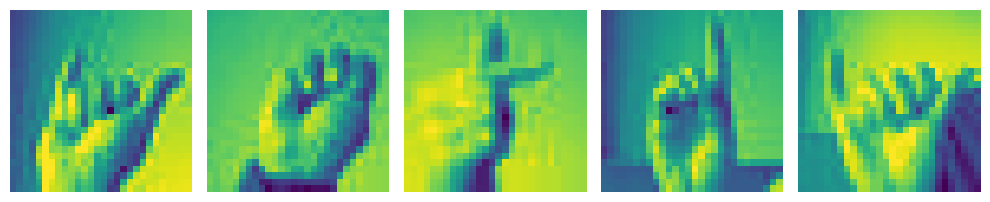

In [ ]:
sample_trainig_images, _ = next(train_generator)
plotImages(sample_trainig_images[:5])

In [ ]:
model_base = tf.keras.models.Sequential([
                                        tf.keras.layers.Flatten(input_shape= (28,28,1)),
                                        tf.keras.layers.Dense(256, activation="relu"),
                                        tf.keras.layers.Dense(128, activation="relu"),
                                        tf.keras.layers.Dense(len(clases), activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,952 (925.59 KB)

 Trainable params: 236,952 (925.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_base.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


history = model_base.fit(
    train_generator,
    epochs = 20,
    validation_data = validation_generator
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.3519 - loss: 2.1954 - val_accuracy: 0.4596 - val_loss: 1.7234
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.6010 - loss: 1.2969 - val_accuracy: 0.5867 - val_loss: 1.3440
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.7074 - loss: 0.9396 - val_accuracy: 0.6568 - val_loss: 1.1293
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.7791 - loss: 0.7209 - val_accuracy: 0.6674 - val_loss: 1.1028
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.8313 - loss: 0.5585 - val_accuracy: 0.6849 - val_loss: 1.0143
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.8713 - loss: 0.4386 - val_accuracy: 0.6961 - val_loss: 0.9687
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9058 - loss: 0.3369 - val_accuracy: 0.7179 - val_loss: 0.9511
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9351 - loss: 0.2562 - val_acc

In [ ]:
results = model_base.evaluate(test_generator)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6782 - loss: 1.7212


In [ ]:
def visualizacion_resultados(history):
  epochs =[i for i in range(20)]
  fig, ax = plt.subplots(1,2)
  train_acc = history.history["accuracy"]
  train_loss = history.history["loss"]
  val_acc = history.history["val_accuracy"]
  val_loss = history.history["val_loss"]
  fig.set_size_inches(16,9)

  ax[0].plot(epochs, train_acc, "go-", label="Entrenamiento Accuracy")
  ax[0].plot(epochs, val_acc, "ro-", label="Validacion  Accuracy")
  ax[0].set_title("Entrenamiento vs Validacion Accuracy")
  ax[0].legend()
  ax[0].set_xlabel("Epochs")
  ax[0].set_ylabel("Accuracy")

  ax[1].plot(epochs, train_loss, "go-", label="Entrenamiento Loss")
  ax[1].plot(epochs, val_loss, "ro-", label="Validacion  Loss")
  ax[1].set_title("Entrenamiento vs Validacion Loss")
  ax[1].legend()
  ax[1].set_xlabel("Epochs")
  ax[1].set_ylabel("Loss")

  plt.show()


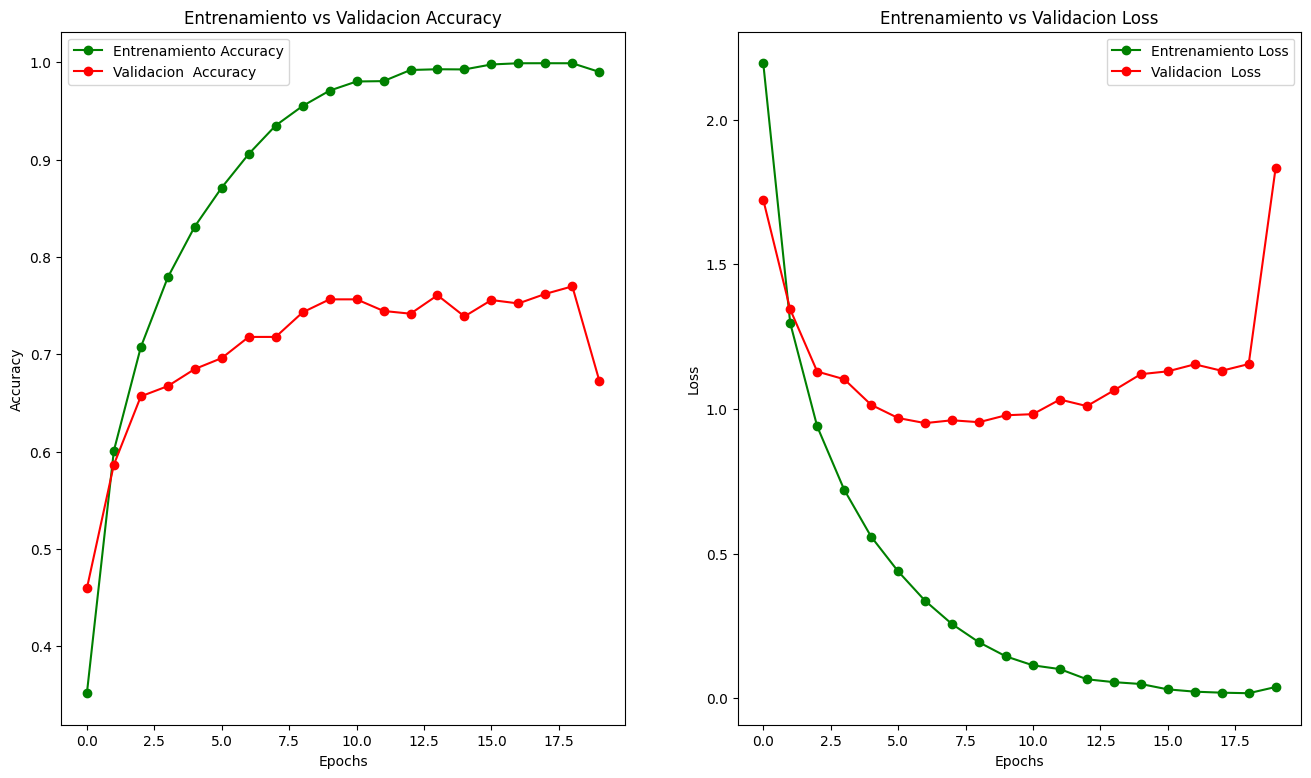

In [ ]:
visualizacion_resultados(history)

In [ ]:
from tensorflow.keras import regularizers

In [ ]:
model_optimizer = tf.keras.models.Sequential([
                                        tf.keras.layers.Flatten(input_shape= (28,28,1)),
                                        tf.keras.layers.Dense(256,kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(128, kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(len(clases), activation="softmax")
])

In [ ]:
model_optimizer.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,952 (925.59 KB)

 Trainable params: 236,952 (925.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_optimizer.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history_optimizer = model_optimizer.fit(
    train_generator,
    epochs = 20,
    validation_data = validation_generator
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.2685 - loss: 2.3764 - val_accuracy: 0.4884 - val_loss: 1.7100
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.4981 - loss: 1.5359 - val_accuracy: 0.5705 - val_loss: 1.3448
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.6000 - loss: 1.2135 - val_accuracy: 0.6295 - val_loss: 1.1369
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.6766 - loss: 0.9791 - val_accuracy: 0.6568 - val_loss: 1.0512
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7159 - loss: 0.8506 - val_accuracy: 0.7067 - val_loss: 0.9679
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.7558 - loss: 0.7379 - val_accuracy: 0.6849 - val_loss: 0.9889
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7804 - loss: 0.6537 - val_accuracy: 0.7095 - val_loss: 0.9180
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.8067 - loss: 0.5737 - val_ac

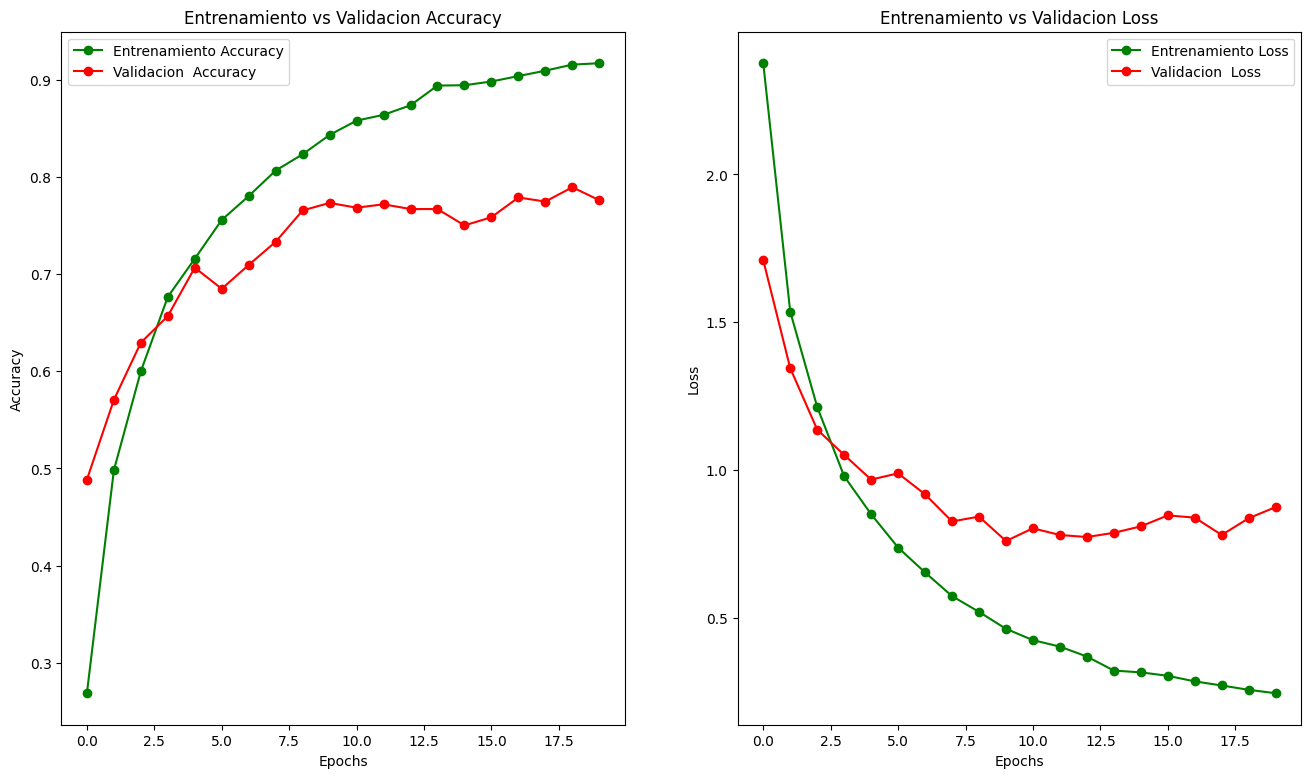

In [ ]:
visualizacion_resultados(history_optimizer)

In [ ]:
model_convolutional = tf.keras.models.Sequential([
                                        tf.keras.layers.Conv2D(75, (3,3),activation="relu", input_shape= (28,28,1)),
                                        tf.keras.layers.MaxPooling2D(2,2),
                                        tf.keras.layers.Flatten(input_shape= (28,28,1)),
                                        tf.keras.layers.Dense(256,kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(128, kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(len(clases), activation="softmax")
])

model_convolutional.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history_convolutional = model_convolutional.fit(
    train_generator,
    epochs = 20,
    validation_data = validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 46s 205ms/step - accuracy: 0.4736 - loss: 1.7457 - val_accuracy: 0.6989 - val_loss: 0.8751
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 44s 204ms/step - accuracy: 0.8820 - loss: 0.3916 - val_accuracy: 0.7811 - val_loss: 0.7061
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 45s 210ms/step - accuracy: 0.9633 - loss: 0.1578 - val_accuracy: 0.8260 - val_loss: 0.6538
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 44s 204ms/step - accuracy: 0.9853 - loss: 0.0841 - val_accuracy: 0.8218 - val_loss: 0.7116
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 43s 202ms/step - accuracy: 0.9918 - loss: 0.0614 - val_accuracy: 0.8365 - val_loss: 0.7175
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 43s 202ms/step - accuracy: 0.9929 - loss: 0.0528 - val_accuracy: 0.8505 - val_loss: 0.7158
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 197ms/step - accuracy: 0.9949 - loss: 0.0447 - val_accuracy: 0.8533 - val_loss: 0.7295
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 194ms/step - accuracy: 0.9956 - loss: 0

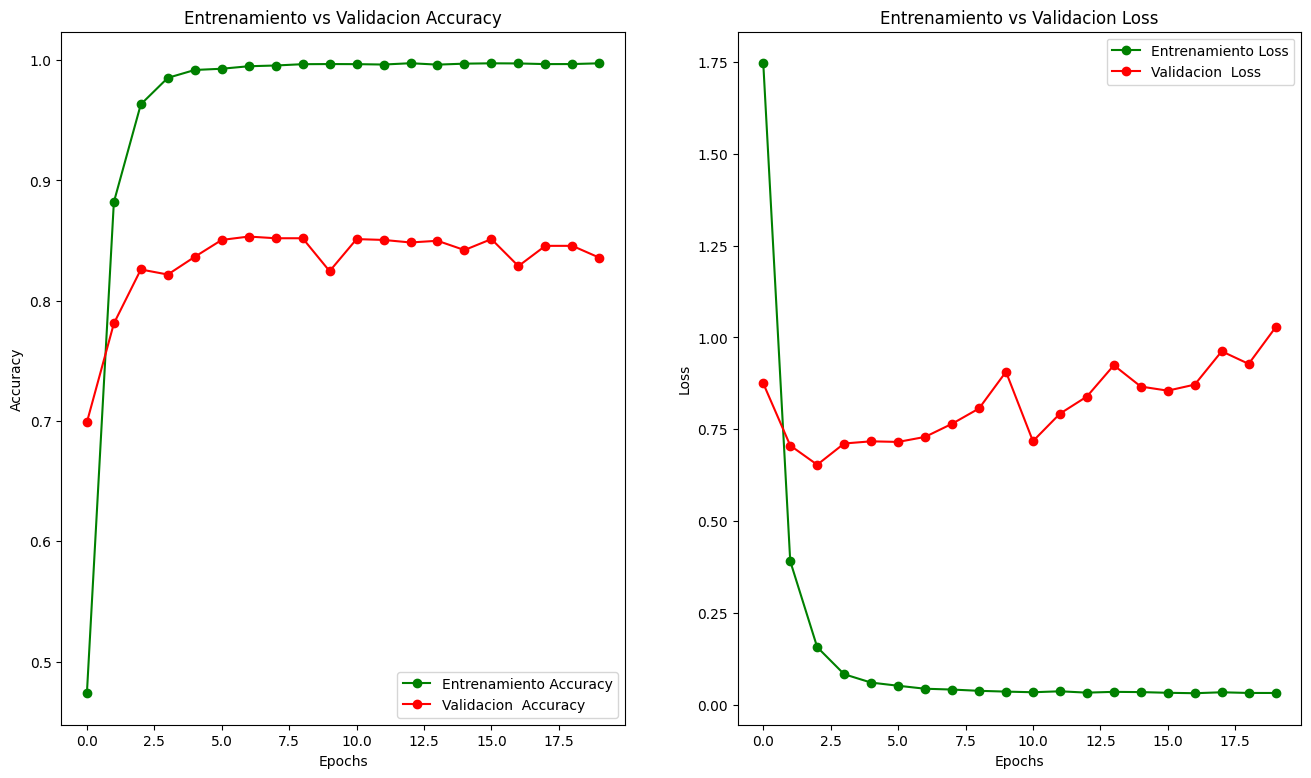

In [ ]:
visualizacion_resultados(history_convolutional)

In [ ]:
#METRICAS callbacks
model_callback = tf.keras.models.Sequential([
                                        tf.keras.layers.Conv2D(75, (3,3),activation="relu", input_shape= (28,28,1)),
                                        tf.keras.layers.MaxPooling2D(2,2),
                                        tf.keras.layers.Flatten(input_shape= (28,28,1)),
                                        tf.keras.layers.Dense(256,kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(128, kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(len(clases), activation="softmax")
])

model_callback.summary()

model_callback.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 75)     │           750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12675)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     3,245,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,281,798 (12.52 MB)

 Trainable params: 3,281,798 (12.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import Callback

In [ ]:
class TrainingCallback(Callback):
  def on_epoch_end(self, epoch, logs={}):
    if logs.get("accuracy") > 0.95:
      print("Lo logramos nuestro modelo llego al 95% , detenemos el entremiento")
      self.model.stop_training = True


In [ ]:
callback = TrainingCallback()

history_callback = model_callback.fit(
    train_generator,
    epochs = 20,
    callbacks=[callback],
    validation_data = validation_generator
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 45s 202ms/step - accuracy: 0.4320 - loss: 1.8510 - val_accuracy: 0.6877 - val_loss: 0.9579
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 43s 201ms/step - accuracy: 0.8535 - loss: 0.4720 - val_accuracy: 0.8098 - val_loss: 0.6062
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9445 - loss: 0.2140Lo logramos nuestro modelo llego al 95% , detenemos el entremiento
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 194ms/step - accuracy: 0.9545 - loss: 0.1802 - val_accuracy: 0.8407 - val_loss: 0.6454


In [ ]:
def get_model():
  model = tf.keras.models.Sequential([
                                        tf.keras.layers.Conv2D(75, (3,3),activation="relu", input_shape= (28,28,1)),
                                        tf.keras.layers.MaxPooling2D(2,2),
                                        tf.keras.layers.Flatten(input_shape= (28,28,1)),
                                        tf.keras.layers.Dense(256,kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(128, kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(len(clases), activation="softmax")
])
  return model

model_early = get_model()
model_early.summary()

model_early.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 75)     │           750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12675)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     3,245,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,281,798 (12.52 MB)

 Trainable params: 3,281,798 (12.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callback_early = tf.keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=3,
    mode = "auto"
)

In [ ]:
history_early = model_early.fit(
    train_generator,
    epochs = 20,
    callbacks=[callback_early],
    validation_data = validation_generator
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 46s 206ms/step - accuracy: 0.4531 - loss: 1.8051 - val_accuracy: 0.7326 - val_loss: 0.8481
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 43s 201ms/step - accuracy: 0.8512 - loss: 0.4762 - val_accuracy: 0.7937 - val_loss: 0.6238
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 197ms/step - accuracy: 0.9455 - loss: 0.2040 - val_accuracy: 0.8274 - val_loss: 0.5905
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 197ms/step - accuracy: 0.9756 - loss: 0.1122 - val_accuracy: 0.8232 - val_loss: 0.6558
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 44s 205ms/step - accuracy: 0.9850 - loss: 0.0777 - val_accuracy: 0.8575 - val_loss: 0.6200
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 43s 200ms/step - accuracy: 0.9895 - loss: 0.0614 - val_accuracy: 0.8372 - val_loss: 0.6677
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 43s 199ms/step - accuracy: 0.9920 - loss: 0.0532 - val_accuracy: 0.8456 - val_loss: 0.6791
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 43s 198ms/step - accuracy: 0.9929 - loss: 0

In [ ]:
!pip install -q -U keras-tuner
import kerastuner as kt
from tensorflow import keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.0 MB/s eta 0:00:00


/tmp/ipykernel_13987/2469124855.py:2: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


In [ ]:
def constructo_modelos(hp):
  model = tf.keras.models.Sequential()
  model.add(tf.keras.layers.Conv2D(75,(3,3), activation="relu", input_shape= (28,28,1)))
  model.add(tf.keras.layers.MaxPooling2D((2,2)))
  model.add(tf.keras.layers.Flatten())

  hp_units = hp.Int("units", min_value=32, max_value=512, step=32)
  model.add(tf.keras.layers.Dense(units=hp_units, activation="relu", kernel_regularizer= regularizers.l2(1e-5)))
  model.add(tf.keras.layers.Dropout(0.2))
  model.add(tf.keras.layers.Dense(128, activation="relu", kernel_regularizer= regularizers.l2(1e-5)))
  model.add(tf.keras.layers.Dropout(0.2))
  model.add(tf.keras.layers.Dense(len(clases), activation="softmax"))

  hp_learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4])
  model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate), loss ="categorical_crossentropy", metrics=["accuracy"])

  return model


In [ ]:
tuner = kt.Hyperband(
    constructo_modelos,
    objective="val_accuracy",
    max_epochs= 20,
    factor=3,
    directory="models/",
    project_name="projec-personal"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
tuner.search(train_generator, epochs = 20, validation_data = validation_generator)
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]

Trial 30 Complete [00h 22m 58s]
val_accuracy: 0.03438596427440643

Best val_accuracy So Far: 0.8701754212379456
Total elapsed time: 04h 52m 40s


In [42]:
print (best_hps.get("units"))

448


In [43]:
print (best_hps.get("learning_rate"))

0.001


In [44]:


hypermodel = tuner.hypermodel.build(best_hps)

history_hypermodel = hypermodel.fit(
    train_generator,
    epochs = 20,
    callbacks=[callback_early],
    validation_data = validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 79s 358ms/step - accuracy: 0.4795 - loss: 1.7533 - val_accuracy: 0.7404 - val_loss: 0.8205
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 80s 348ms/step - accuracy: 0.9016 - loss: 0.3403 - val_accuracy: 0.8112 - val_loss: 0.5736
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 73s 341ms/step - accuracy: 0.9748 - loss: 0.1264 - val_accuracy: 0.8463 - val_loss: 0.5793
